In [ ]:
import torch
from torch import nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Dataset

transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

training_data = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_data = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

batch_size = 32

train_dataloader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=100)

Files already downloaded and verified
Files already downloaded and verified


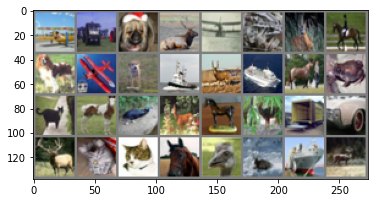

['plane', 'truck', 'dog', 'deer', 'plane', 'frog', 'deer', 'horse', 'dog', 'plane', 'dog', 'ship', 'deer', 'ship', 'horse', 'frog', 'cat', 'horse', 'bird', 'deer', 'horse', 'deer', 'truck', 'car', 'deer', 'cat', 'cat', 'horse', 'bird', 'deer', 'ship', 'deer']


In [ ]:
# Plot some images

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

def imshow(img):
    img = img / 2 + 0.5 # Unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

dataiter = iter(train_dataloader)
images, labels = dataiter.next()

imshow(torchvision.utils.make_grid(images))
print([classes[labels[j]] for j in range(batch_size)])

In [ ]:
# Dataset shape

images.shape

torch.Size([32, 3, 32, 32])

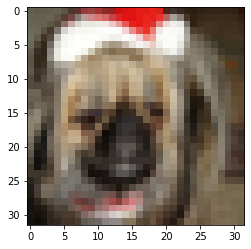

In [ ]:
imshow(images[2])

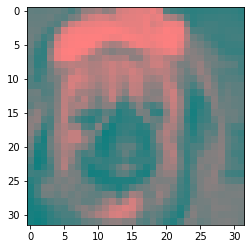

In [ ]:
# Red channel

im_red = images[2].clone()
im_red[1:3,:,:] = 0.
imshow(im_red)

In [ ]:
# Convolutional model

class NeuralNetwork(nn.Module):
    
    def __init__(self):

        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):

        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x

model = NeuralNetwork()

In [ ]:
# Training

model = NeuralNetwork()

loss_fn = nn.CrossEntropyLoss()

learning_rate = 0.01
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

epochs = 5

for epoch in range(epochs):

    running_loss = 0.0

    for i, data in enumerate(train_dataloader, 0):

        inputs, labels = data

        outputs = model(inputs) # Forward
        loss = loss_fn(outputs, labels)

        optimizer.zero_grad()
        loss.backward() # Backward
        optimizer.step() # Gradient step

        running_loss += loss.item()
        print_every = 200
        if i % print_every == print_every - 1:
            print(f'epoch {epoch + 1} \t batch {i + 1} \t loss: {(running_loss/print_every):.3f}')
            running_loss = 0.0

print('Done!')

epoch 1 	 batch 200 	 loss: 2.303
epoch 1 	 batch 400 	 loss: 2.302
epoch 1 	 batch 600 	 loss: 2.299
epoch 1 	 batch 800 	 loss: 2.296
epoch 1 	 batch 1000 	 loss: 2.288
epoch 1 	 batch 1200 	 loss: 2.263
epoch 1 	 batch 1400 	 loss: 2.169
epoch 2 	 batch 200 	 loss: 2.014
epoch 2 	 batch 400 	 loss: 1.938
epoch 2 	 batch 600 	 loss: 1.879
epoch 2 	 batch 800 	 loss: 1.842
epoch 2 	 batch 1000 	 loss: 1.794
epoch 2 	 batch 1200 	 loss: 1.767
epoch 2 	 batch 1400 	 loss: 1.747
epoch 3 	 batch 200 	 loss: 1.670
epoch 3 	 batch 400 	 loss: 1.667
epoch 3 	 batch 600 	 loss: 1.639
epoch 3 	 batch 800 	 loss: 1.651
epoch 3 	 batch 1000 	 loss: 1.606
epoch 3 	 batch 1200 	 loss: 1.596
epoch 3 	 batch 1400 	 loss: 1.577
epoch 4 	 batch 200 	 loss: 1.553
epoch 4 	 batch 400 	 loss: 1.533
epoch 4 	 batch 600 	 loss: 1.524
epoch 4 	 batch 800 	 loss: 1.526
epoch 4 	 batch 1000 	 loss: 1.513
epoch 4 	 batch 1200 	 loss: 1.467
epoch 4 	 batch 1400 	 loss: 1.484
epoch 5 	 batch 200 	 loss: 1.443
ep

In [ ]:
# Inference

correct = 0
total = 0

with torch.no_grad():

    for data in test_dataloader:

        images, labels = data

        outputs = model(images)

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Test accuracy: {100 * correct / total}')

Test accuracy: 49.32


In [ ]:
# Training with momentum

model = NeuralNetwork()

loss_fn = nn.CrossEntropyLoss()

learning_rate = 0.01
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=.9)

epochs = 5

for epoch in range(epochs):

    running_loss = 0.0

    for i, data in enumerate(train_dataloader, 0):

        inputs, labels = data

        outputs = model(inputs) # Forward
        loss = loss_fn(outputs, labels)

        optimizer.zero_grad()
        loss.backward() # Backward
        optimizer.step() # Gradient step

        running_loss += loss.item()
        print_every = 200
        if i % print_every == print_every - 1:
            print(f'epoch {epoch + 1} \t batch {i + 1} \t loss: {(running_loss/print_every):.3f}')
            running_loss = 0.0

print('Done!')

epoch 1 	 batch 200 	 loss: 2.218
epoch 1 	 batch 400 	 loss: 1.897
epoch 1 	 batch 600 	 loss: 1.734
epoch 1 	 batch 800 	 loss: 1.620
epoch 1 	 batch 1000 	 loss: 1.569
epoch 1 	 batch 1200 	 loss: 1.534
epoch 1 	 batch 1400 	 loss: 1.493
epoch 2 	 batch 200 	 loss: 1.395
epoch 2 	 batch 400 	 loss: 1.395
epoch 2 	 batch 600 	 loss: 1.379
epoch 2 	 batch 800 	 loss: 1.327
epoch 2 	 batch 1000 	 loss: 1.335
epoch 2 	 batch 1200 	 loss: 1.321
epoch 2 	 batch 1400 	 loss: 1.301
epoch 3 	 batch 200 	 loss: 1.233
epoch 3 	 batch 400 	 loss: 1.226
epoch 3 	 batch 600 	 loss: 1.204
epoch 3 	 batch 800 	 loss: 1.170
epoch 3 	 batch 1000 	 loss: 1.182
epoch 3 	 batch 1200 	 loss: 1.196
epoch 3 	 batch 1400 	 loss: 1.201
epoch 4 	 batch 200 	 loss: 1.086
epoch 4 	 batch 400 	 loss: 1.122
epoch 4 	 batch 600 	 loss: 1.102
epoch 4 	 batch 800 	 loss: 1.114
epoch 4 	 batch 1000 	 loss: 1.116
epoch 4 	 batch 1200 	 loss: 1.123
epoch 4 	 batch 1400 	 loss: 1.126
epoch 5 	 batch 200 	 loss: 1.013
ep

In [ ]:
# Inference

correct = 0
total = 0

with torch.no_grad():

    for data in test_dataloader:

        images, labels = data

        outputs = model(images)

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Test accuracy: {100 * correct / total}')

Test accuracy: 61.03


In [ ]:
from torchvision.models.feature_extraction import get_graph_node_names

nodes, _ = get_graph_node_names(model)
print(nodes)

['x', 'conv1', 'relu', 'pool', 'conv2', 'relu_1', 'pool_1', 'flatten', 'fc1', 'relu_2', 'fc2', 'relu_3', 'fc3']


In [ ]:
from torchvision.models.feature_extraction import create_feature_extractor

feature_extractor = create_feature_extractor(
	model, return_nodes=['conv1', 'relu', 'pool'])

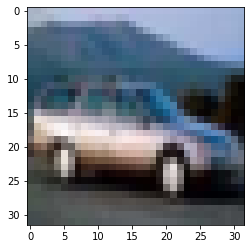

In [ ]:
dataloader = DataLoader(training_data, batch_size=batch_size)

dataiter = iter(dataloader)
images, labels = dataiter.next()

id = 4
imshow(images[id])

out = feature_extractor(images[id].unsqueeze(0))

conv1


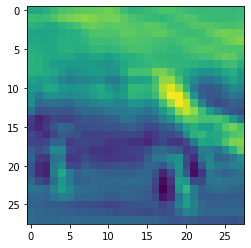

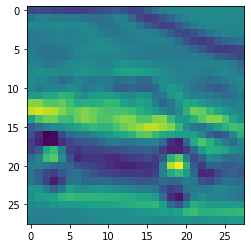

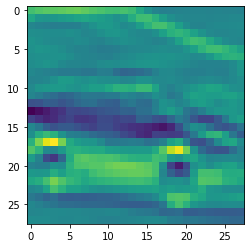

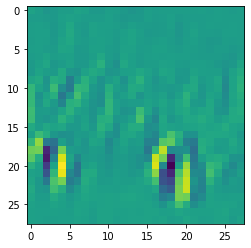

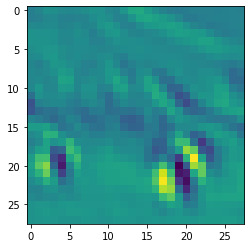

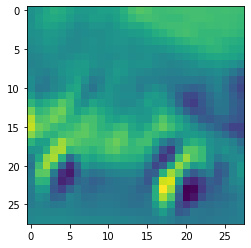

relu


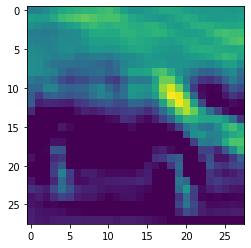

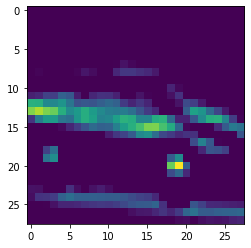

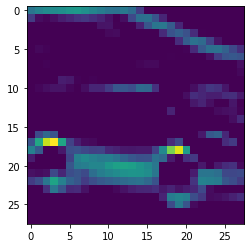

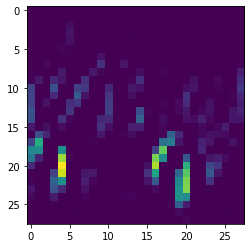

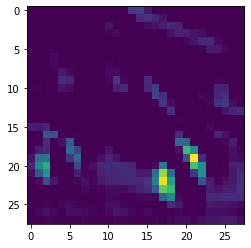

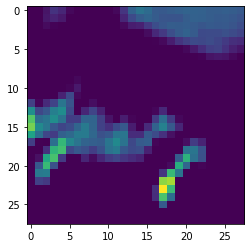

pool


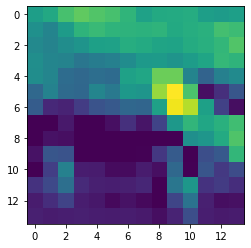

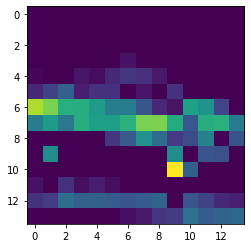

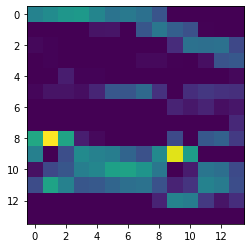

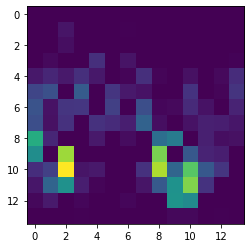

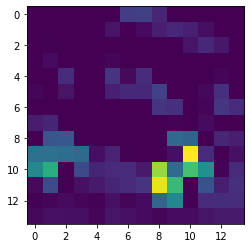

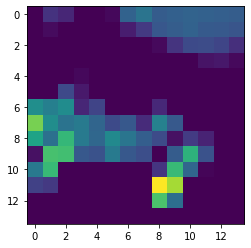

In [ ]:
print('conv1')
for i in range(6):
    plt.imshow(out['conv1'][0,i].detach())
    plt.show()

print('relu')
for i in range(6):
    plt.imshow(out['relu'][0,i].detach())
    plt.show()

print('pool')
for i in range(6):
    plt.imshow(out['pool'][0,i].detach())
    plt.show()

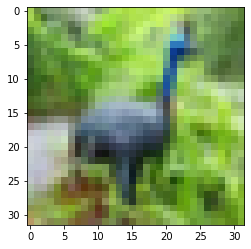

In [ ]:
id = 6
imshow(images[id])

out = feature_extractor(images[id].unsqueeze(0))

conv1


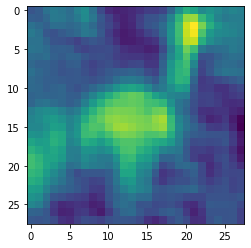

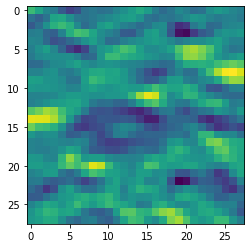

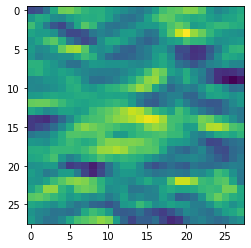

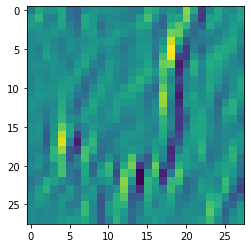

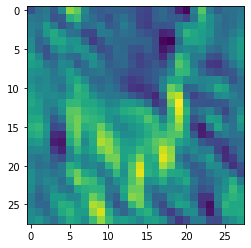

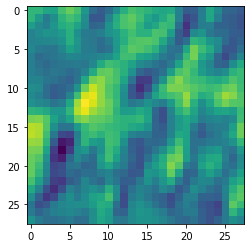

relu


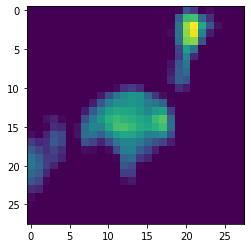

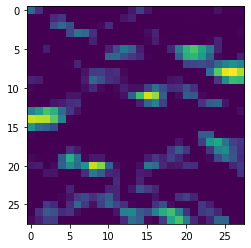

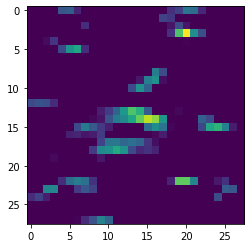

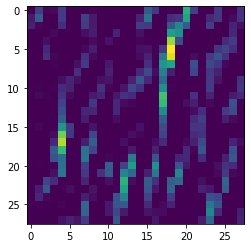

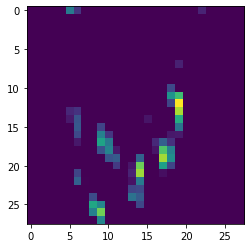

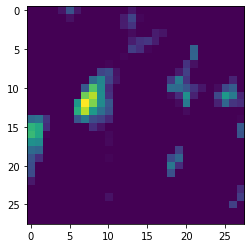

pool


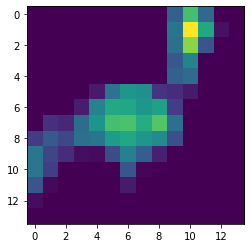

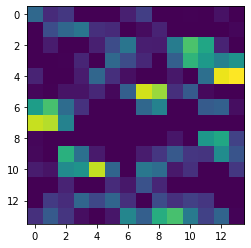

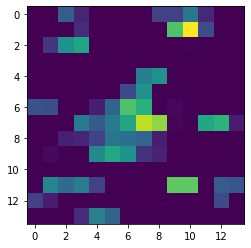

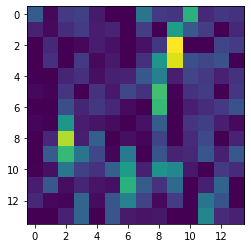

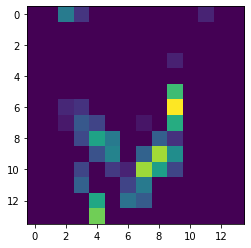

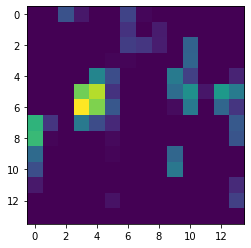

In [ ]:
print('conv1')
for i in range(6):
    plt.imshow(out['conv1'][0,i].detach())
    plt.show()

print('relu')
for i in range(6):
    plt.imshow(out['relu'][0,i].detach())
    plt.show()

print('pool')
for i in range(6):
    plt.imshow(out['pool'][0,i].detach())
    plt.show()